In [1]:
# Environment setup for faster runs
import torch
torch.backends.cudnn.benchmark = True   # speeds up training
torch.cuda.empty_cache()

# Braille Dot Detection - Complete Notebook

This notebook combines all the Python modules (dataset, evaluate, model, test, train, utils) into a single Colab-compatible notebook for Braille dot detection using a U-Net architecture with ResNet-18 encoder.

## 1. Installation and Setup

Install required packages if not already installed.

In [2]:
# # Install required packages (uncomment if needed)
# %pip install torch torchvision opencv-python scikit-learn matplotlib numpy scipy


## 2. Imports

Import all necessary libraries.

In [3]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from scipy.spatial import cKDTree


## 3. Utils Functions

Utility functions for image preprocessing, annotation parsing, Gaussian map generation, and visualization.

In [4]:
# ========== UTILS.PY ==========

def preprocess_image(img, size=(512, 512)):
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img

def parse_annotation(txt_path, img_shape):
    """Parse DSBI annotation file and return list of (x, y) dot centers."""
    h, w = img_shape
    with open(txt_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    if len(lines) < 4:
        return []

    angle = float(lines[0])
    verticals = np.array(list(map(float, lines[1].split())))
    horizontals = np.array(list(map(float, lines[2].split())))

    coords = []
    for cell in lines[3:]:
        vals = list(map(int, cell.split()))
        if len(vals) != 8:
            continue
        row, col = vals[0], vals[1]
        dots = vals[2:]

        if 2*(col-1)+1 >= len(verticals) or 3*(row-1)+3 >= len(horizontals):
            continue

        x0, x1 = verticals[2*(col-1)], verticals[2*(col-1)+1]
        y0, y3 = horizontals[3*(row-1)], horizontals[3*(row-1)+3]
        dx, dy = (x1 - x0)/2, (y3 - y0)/3

        centers = [
            (x0 + dx/2, y0 + dy/2),
            (x0 + dx/2, y0 + 1.5*dy),
            (x0 + dx/2, y0 + 2.5*dy),
            (x0 + 1.5*dx, y0 + dy/2),
            (x0 + 1.5*dx, y0 + 1.5*dy),
            (x0 + 1.5*dx, y0 + 2.5*dy),
        ]
        for i in range(6):
            if dots[i] == 1:
                coords.append(centers[i])
    return coords

def generate_gaussian_map(shape, coords, sigma=2):
    h, w = shape
    yv, xv = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    heatmap = np.zeros((h, w), dtype=np.float32)
    for (x, y) in coords:
        heatmap += np.exp(-((xv - x)**2 + (yv - y)**2) / (2 * sigma**2))
    heatmap = np.clip(heatmap, 0, 1)
    return heatmap


def visualize(img, gt, pred=None):
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title("Input")
    plt.subplot(1,3,2); plt.imshow(gt, cmap='hot'); plt.title("Ground Truth")
    if pred is not None:
        plt.subplot(1,3,3); plt.imshow(pred, cmap='hot'); plt.title("Prediction")
    plt.show()

## 4. Model Definition

U-Net architecture with ResNet-18 encoder for Braille dot detection.

In [5]:
# ========== MODEL.PY ==========

# ---------------------------
# Upsampling Block (U-Net)
# ---------------------------
class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_ch, out_ch, kernel_size=2, stride=2
        )
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


# ---------------------------
# Braille Dot Detection Network
# ---------------------------
class BddNet(nn.Module):
    def __init__(self, input_size=512):
        super().__init__()
        self.input_size = input_size

        # -------- ResNet-18 Encoder --------
        resnet = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        # ---- Grayscale input (1 channel) ----
        old_conv = resnet.conv1
        resnet.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        resnet.conv1.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)

        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # 64
        self.pool = resnet.maxpool                                      # ↓
        self.enc2 = resnet.layer1                                       # 64
        self.enc3 = resnet.layer2                                       # 128
        self.enc4 = resnet.layer3                                       # 256
        self.enc5 = resnet.layer4                                       # 512

        # -------- Bottleneck --------
        self.center = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # -------- Decoder (FIXED) --------
        self.up4 = UpBlock(256, 256, 128)
        self.up3 = UpBlock(128, 128, 64)
        self.up2 = UpBlock(64, 64, 32)
        self.up1 = UpBlock(32, 64, 64)

        # -------- Final Heatmap --------
        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # -------- Encoder --------
        e1 = self.enc1(x)             # [B, 64,  H/2,  W/2]
        e2 = self.enc2(self.pool(e1)) # [B, 64,  H/4,  W/4]
        e3 = self.enc3(e2)            # [B, 128, H/8,  W/8]
        e4 = self.enc4(e3)            # [B, 256, H/16, W/16]
        e5 = self.enc5(e4)            # [B, 512, H/32, W/32]

        # -------- Center --------
        c = self.center(e5)           # [B, 256, H/32, W/32]

        # -------- Decoder --------
        x = self.up4(c, e4)           # [B, 128, H/16, W/16]
        x = self.up3(x, e3)           # [B, 64,  H/8,  W/8]
        x = self.up2(x, e2)           # [B, 32,  H/4,  W/4]
        x = self.up1(x, e1)           # [B, 64,  H/2,  W/2]

        x = self.final(x)             # [B, 1,   H/2,  W/2]

        # -------- Resize to GT size --------
        x = F.interpolate(
            x,
            size=(self.input_size, self.input_size),
            mode="bilinear",
            align_corners=False
        )

        return torch.sigmoid(x)

## 5. Dataset Class

PyTorch Dataset class for loading Braille images and annotations.

In [6]:
# ========== DATASET.PY ==========

class BrailleDataset(Dataset):
    def __init__(self, list_path, base_dir, sigma=2, img_size=(512, 512), augment=False):
        with open(list_path) as f:
            self.samples = [line.strip() for line in f if line.strip()]
        self.base_dir = base_dir
        self.sigma = sigma
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rel_path = self.samples[idx]
        img_path = os.path.join(self.base_dir, rel_path + "+recto.jpg")
        ann_path = os.path.join(self.base_dir, rel_path + "+recto.txt")

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(img_path)
        img = cv2.resize(img, self.img_size, interpolation=cv2.INTER_AREA)
        try:
            dots = parse_annotation(ann_path, img.shape)
        except (FileNotFoundError, Exception) as e:
            print(f"Warning: Error parsing {ann_path}: {e}")
            dots = []
        gt = generate_gaussian_map(img.shape, dots, sigma=self.sigma)
        # Normalize image to [0, 1]
        img = preprocess_image(img, self.img_size)

        img = torch.from_numpy(img).unsqueeze(0).float()
        gt = torch.from_numpy(gt).unsqueeze(0).float()
        return img, gt

## 6. Evaluation Functions

Functions for evaluating model performance using precision, recall, and F1 score.

In [7]:
# ========== EVALUATE.PY ==========

def extract_dots(pred_map, thresh=0.5):
    mask = (pred_map > thresh).astype(np.uint8)
    num, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    return centroids[1:]  # skip background

def compare_dots(pred, gt, dist_thresh=10):
    if len(gt) == 0 or len(pred) == 0:
        return 0, len(pred), len(gt)
    tree = cKDTree(gt)
    dists, idx = tree.query(pred, distance_upper_bound=dist_thresh)
    tp = np.sum(dists != np.inf)
    fp = len(pred) - tp
    fn = len(gt) - tp
    return tp, fp, fn

def evaluate_model(model, val_loader, device="cpu"):
    model.eval()
    TP=FP=FN=0
    with torch.no_grad():
        for imgs, gts in val_loader:
            imgs = imgs.to(device)
            preds = model(imgs).cpu().numpy()
            for i in range(len(preds)):
                pred_map = preds[i,0]
                gt_map = gts[i,0].numpy()
                gt_coords = extract_dots(gt_map, 0.5)
                pr_coords = extract_dots(pred_map, 0.5)
                tp, fp, fn = compare_dots(pr_coords, gt_coords)
                TP+=tp; FP+=fp; FN+=fn
    precision = TP/(TP+FP+1e-6)
    recall = TP/(TP+FN+1e-6)
    f1 = 2*precision*recall/(precision+recall+1e-6)
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    return precision, recall, f1

## 7. Training Function

Function to train the Braille dot detection model.

In [8]:
# ========== TRAIN.PY ==========

def train(train_list, base_dir, save_path="checkpoints", epochs=100, batch_size=2, lr=1e-4):
    print(">>> Starting training function")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(">>> Device:", device)

    model = BddNet().to(device)
    print(">>> Model loaded")

    dataset = BrailleDataset(train_list, base_dir)
    print(">>> Dataset size:", len(dataset))

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,      # Use 0 for Colab compatibility
        pin_memory=False
    )
    print(">>> DataLoader ready")

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    # Create save directory if it doesn't exist
    os.makedirs(save_path, exist_ok=True)
    scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None

    for epoch in range(1, epochs + 1):
        print(f">>> Epoch {epoch} started")
        model.train()
        epoch_loss = 0.0

        for i, (imgs, gts) in enumerate(loader):
            imgs, gts = imgs.to(device), gts.to(device)

            opt.zero_grad()
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    preds = model(imgs)
                    loss = loss_fn(preds, gts)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                preds = model(imgs)
                loss = loss_fn(preds, gts)
                loss.backward()
                opt.step()

            epoch_loss += loss.item()
            if (i + 1) % 10 == 0:
                print(f"   Batch {i+1}/{len(loader)}, loss: {loss.item():.6f}")

        avg_loss = epoch_loss / len(loader)
        print(f">>> Epoch {epoch} finished, Average Loss: {avg_loss:.6f}")

        # Save checkpoint periodically
        if epoch % 5 == 0:
            checkpoint_path = os.path.join(save_path, f"checkpoint_epoch_{epoch}.pt")
            torch.save(model.state_dict(), checkpoint_path)
            print(f">>> Checkpoint saved: {checkpoint_path}")

    # Save final model
    final_path = os.path.join(save_path, "final_model.pt")
    torch.save(model.state_dict(), final_path)
    print(f">>> Final model saved: {final_path}")
    
    return model

## 8. Test/Inference Function

Function to run inference on a single image.

In [9]:
# ========== TEST.PY ==========

def infer_single(image_path, checkpoint, out_path=None):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = BddNet().to(device)
    model.load_state_dict(torch.load(checkpoint, map_location=device))
    model.eval()

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    
    inp = preprocess_image(img)
    inp = torch.from_numpy(inp).unsqueeze(0).unsqueeze(0).float().to(device)
    with torch.no_grad():
        pred = model(inp)[0,0].cpu().numpy()
    visualize(img, np.zeros_like(img), pred)
    if out_path:
        cv2.imwrite(out_path, (pred*255).astype(np.uint8))
    return pred

## 9. Example Usage

### 9.1 Training Example

To train the model, uncomment and modify the following cell with your data paths:

In [10]:
# Example training (uncomment and modify paths as needed)
train_list = "../dummy_train.txt"  # Path to file containing list of training samples
base_dir = "../data/"              # Base directory containing images and annotations
save_path = "checkpoints"               # Directory to save model checkpoints
epochs = 100                            # Number of training epochs
batch_size = 2                          # Batch size

model = train(train_list, base_dir, save_path, epochs, batch_size)

>>> Starting training function
>>> Device: cuda
>>> Model loaded
>>> Dataset size: 26
>>> DataLoader ready
>>> Epoch 1 started


C:\Users\rohan\AppData\Local\Temp\ipykernel_1628\1368417344.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None
C:\Users\rohan\AppData\Local\Temp\ipykernel_1628\1368417344.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


   Batch 10/13, loss: 0.351342
>>> Epoch 1 finished, Average Loss: 0.374370
>>> Epoch 2 started
   Batch 10/13, loss: 0.264619
>>> Epoch 2 finished, Average Loss: 0.278855
>>> Epoch 3 started
   Batch 10/13, loss: 0.215667
>>> Epoch 3 finished, Average Loss: 0.222761
>>> Epoch 4 started
   Batch 10/13, loss: 0.186887
>>> Epoch 4 finished, Average Loss: 0.192909
>>> Epoch 5 started
   Batch 10/13, loss: 0.167999
>>> Epoch 5 finished, Average Loss: 0.172859
>>> Checkpoint saved: checkpoints\checkpoint_epoch_5.pt
>>> Epoch 6 started
   Batch 10/13, loss: 0.157504
>>> Epoch 6 finished, Average Loss: 0.160530
>>> Epoch 7 started
   Batch 10/13, loss: 0.149007
>>> Epoch 7 finished, Average Loss: 0.151873
>>> Epoch 8 started
   Batch 10/13, loss: 0.143758
>>> Epoch 8 finished, Average Loss: 0.144922
>>> Epoch 9 started
   Batch 10/13, loss: 0.138151
>>> Epoch 9 finished, Average Loss: 0.139133
>>> Epoch 10 started
   Batch 10/13, loss: 0.134934
>>> Epoch 10 finished, Average Loss: 0.135495
>>

### 9.2 Evaluation Example

To evaluate the model on a validation set:

In [11]:
# Example evaluation (uncomment and modify paths as needed)
val_list = "../dummy_test.txt"      # Path to file containing list of validation samples
base_dir = "../data/"              # Base directory containing images and annotations
checkpoint = "checkpoints/final_model.pt"  # Path to trained model checkpoint

device = "cuda" if torch.cuda.is_available() else "cpu"
model = BddNet().to(device)
model.load_state_dict(torch.load(checkpoint, map_location=device))

val_dataset = BrailleDataset(val_list, base_dir)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0)  # Use 0 for Colab compatibility

precision, recall, f1 = evaluate_model(model, val_loader, device)

C:\Users\rohan\AppData\Local\Temp\ipykernel_1628\2171236566.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint, map_location=dev

Precision: 0.0000, Recall: 0.0000, F1: 0.0000


### 9.3 Inference Example

To run inference on a single image:

C:\Users\rohan\AppData\Local\Temp\ipykernel_1628\4188511750.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint, map_location=dev

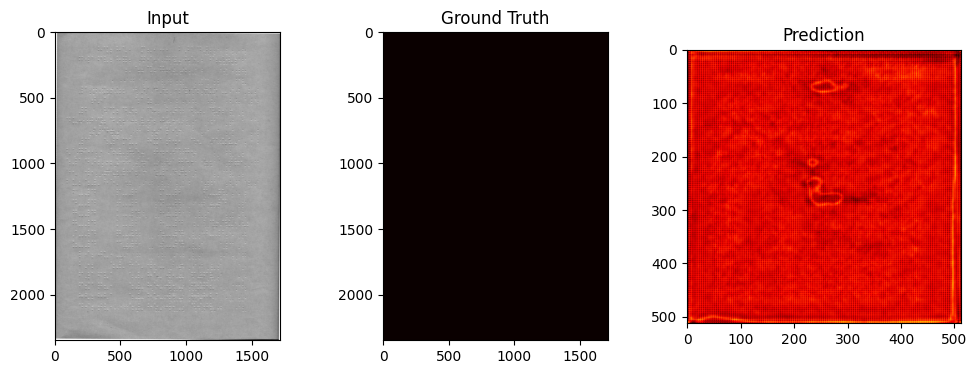

In [13]:
# Example inference (uncomment and modify paths as needed)
image_path = "..\data\Ordinary Printed Document\OPD+1+recto.jpg"   # Path to input image
checkpoint = "checkpoints/final_model.pt"  # Path to trained model checkpoint
output_path = "output_prediction.jpg"   # Path to save prediction (optional)

pred = infer_single(image_path, checkpoint, output_path)